In [5]:
import pandas as pd

In [6]:
df = pd.read_csv(
    "../data/raw/twcs/twcs.csv",
    nrows=10000
)

In [7]:
df = df[df["inbound"] == True]

In [8]:
df = df[["text"]]

In [9]:
df.head(10)

,text
1,@sprintcare and how do you propose we do that
2,@sprintcare I have sent several private messag...
4,@sprintcare I did.
6,@sprintcare is the worst customer service
8,@sprintcare You gonna magically change your co...
10,@sprintcare Since I signed up with you....Sinc...
12,@115714 y’all lie about your “great” connectio...
14,"@115714 whenever I contact customer support, t..."
16,@Ask_Spectrum Would you like me to email you a...
18,@Ask_Spectrum I received this from your corpor...


In [22]:
def assign_intent(text):

    text = str(text).lower()

    # =========================
    # COMPLAINT
    # =========================
    if any(word in text for word in [

        "worst",
        "bad",
        "terrible",
        "awful",
        "hate",
        "angry",
        "annoying",
        "ridiculous",
        "garbage",
        "sucks",
        "suck",
        "bullshit",
        "wtf",
        "frustrated",
        "not happy",
        "disappointed",
        "unacceptable",
        "horrible",
        "epic fail",
        "shame",
        "useless",
        "shit",
        "crap",
        "discriminatory",
        "fake news",
        "stupid",
        "idiots",
        "lied",
        "lie",
        "broken service",
        "poor service"

    ]):
        return "complaint"


    # =========================
    # REFUND
    # =========================
    elif any(word in text for word in [

        "refund",
        "money back",
        "refunded",
        "refund me",
        "cancel my reservation",
        "return my money",
        "delivery charge"

    ]):
        return "refund_request"


    # =========================
    # DELIVERY
    # =========================
    elif any(word in text for word in [

        "delivery",
        "delivered",
        "shipment",
        "shipping",
        "package",
        "tracking",
        "arrive",
        "arrived",
        "late",
        "driver",
        "out for delivery",
        "wrong country",
        "not delivered",
        "pickup order"

    ]):
        return "delivery_issue"


    # =========================
    # TECHNICAL SUPPORT
    # =========================
    elif any(word in text for word in [

        "error",
        "bug",
        "issue",
        "problem",
        "not working",
        "doesn't work",
        "doesnt work",
        "crash",
        "crashed",
        "freeze",
        "stuck",
        "wifi",
        "internet",
        "app",
        "ios",
        "battery",
        "screen",
        "sync",
        "loading",
        "connection",
        "connectivity",
        "broken link",
        "404",
        "update",
        "diagnostic",
        "technical",
        "router",
        "slow",
        "lag",
        "service going"

    ]):
        return "technical_support"


    # =========================
    # PAYMENT
    # =========================
    elif any(word in text for word in [

        "payment",
        "pay",
        "paid",
        "charged",
        "credit card",
        "bill",
        "balance",
        "bank",
        "money",
        "verify payment",
        "double charged",
        "charged twice"

    ]):
        return "payment_issue"


    # =========================
    # ACCOUNT
    # =========================
    elif any(word in text for word in [

        "account",
        "login",
        "log in",
        "password",
        "sign in",
        "verify",
        "locked",
        "unlock",
        "cannot validate",
        "can't log in",
        "cant log in",
        "account takeover"

    ]):
        return "account_problem"


    # =========================
    # POSITIVE FEEDBACK
    # =========================
    elif any(word in text for word in [

        "thank you",
        "thanks",
        "great",
        "awesome",
        "love",
        "helped",
        "appreciate",
        "best",
        "quick action",
        "fixed",
        "helpful",
        "resolved",
        "fan for life",
        "cheers"

    ]):
        return "positive_feedback"


    # =========================
    # DEFAULT
    # =========================
    else:
        return "general_question"

In [23]:
df["intent"] = df["text"].apply(assign_intent)

In [24]:
df.head(20)

,text,intent
1,@sprintcare and how do you propose we do that,general_question
2,@sprintcare I have sent several private messag...,general_question
4,@sprintcare I did.,general_question
6,@sprintcare is the worst customer service,complaint
8,@sprintcare You gonna magically change your co...,technical_support
10,@sprintcare Since I signed up with you....Sinc...,general_question
12,@115714 y’all lie about your “great” connectio...,complaint
14,"@115714 whenever I contact customer support, t...",account_problem
16,@Ask_Spectrum Would you like me to email you a...,general_question
18,@Ask_Spectrum I received this from your corpor...,general_question


In [25]:
import matplotlib.pyplot as plt

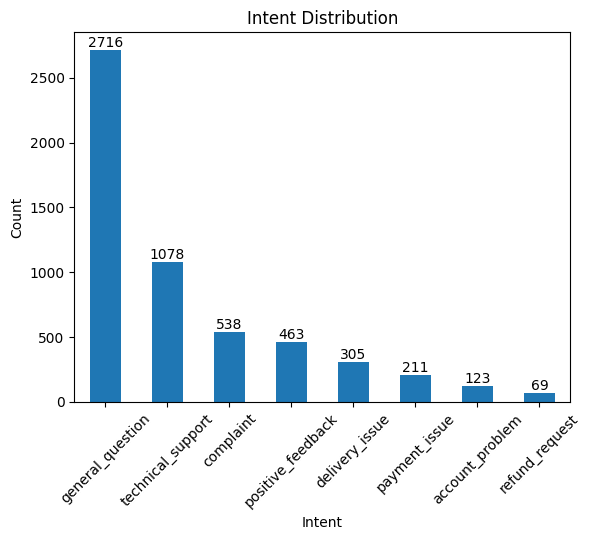

In [28]:
ax = df["intent"].value_counts().plot(kind="bar")

for p in ax.patches:
    ax.annotate(
        str(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Intent Distribution")
plt.xlabel("Intent")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [27]:
df.to_csv(
    "../data/processed/customer_support_clean.csv",
    index=False
)